In [3]:
%pip install pandas
%pip install scikit-learn
%pip install tensorflow
%pip install matplotlib
%pip install imbalanced-learn
%env SCIPY_ARRAY_API=1

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
env: SCIPY_ARRAY_API=1


In [4]:
# 📦 Imports
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.utils.data_utils import load_and_preprocess_data
from src.model import build_weighted_model  # make sure this is imported
import csv
import pandas as pd
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score

In [ ]:
# import os
# print(os.getcwd())  # Current working directory
# print(os.listdir(os.getcwd()))  # What's in the current folder
# print(os.listdir("../src/utils"))  # What's inside the utils folder

/Users/LucaZagaia/Public/Documents/University/TUB/Bachelorthesis/Predictive Maintenance/notebooks
['06_batch_inference.ipynb', '07_realtime_simulation.ipynb', '04_advanced_ensemble.ipynb', '03_hybrid_ensemble.ipynb', 'results', '01_exploration.ipynb', '05_single_inference.ipynb', '00_inference.ipynb', '02_recall_boosting.ipynb']
['__init__.py', '__pycache__', 'data_utils.py', 'fallback_utils.py']


In [13]:
# 1. Load and preprocess the dataset
(X_train, X_test, y_train, y_test), scaler = load_and_preprocess_data("../data/dataset.csv")

In [14]:
from tensorflow.keras.models import load_model
model = load_model("../models/cnn_rnn_model_dataset.keras")

2025-07-03 12:04:13.384928: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-07-03 12:04:13.385552: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-07-03 12:04:13.385603: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-07-03 12:04:13.385641: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-03 12:04:13.385673: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


12/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  

2025-07-03 12:04:17.920228: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
✅ Best Weight: 0.10
📈 Best F1 Score: 0.7317

📊 Ensemble Model Classification Report:

              precision    recall  f1-score   support

           0     0.9917    0.9912    0.9915      1939
           1     0.7258    0.7377    0.7317        61

    accuracy                         0.9835      2000
   macro avg     0.8588    0.8645    0.8616      2000
weighted avg     0.9836    0.9835    0.9836      2000



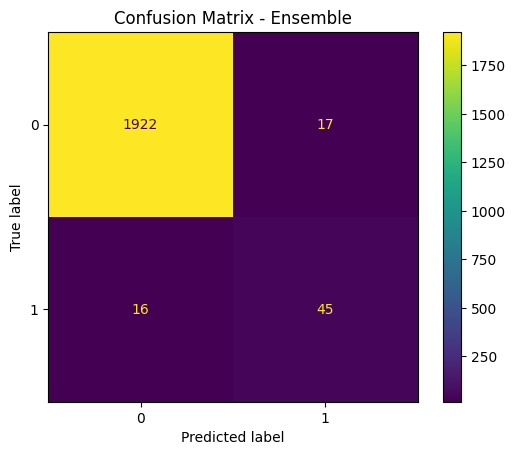

In [15]:
# ⚙️ Step 1: Flatten and train Random Forest
X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf = X_test.reshape(X_test.shape[0], -1)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train)
rf_probs = rf.predict_proba(X_test_rf)[:, 1]

# 🧠 Step 2: Predict with CNN-RNN (already trained)
cnn_probs = model.predict(X_test).flatten()

# 🤝 Step 3: Combine predictions
# ensemble_probs = (cnn_probs + rf_probs) / 2
# threshold = 0.36
# ensemble_preds = (ensemble_probs > threshold).astype(int)

# Threshold from earlier experiment
threshold = 0.36

# Variables to store the best result
best_f1 = 0
best_weight = 0

# Try different weights: 0.0 (only RF) → 1.0 (only CNN-RNN)
for w in np.linspace(0, 1, 21):  # 0.00, 0.05, ..., 1.00
    ensemble_probs_temp = w * cnn_probs + (1 - w) * rf_probs
    y_pred_temp = (ensemble_probs_temp > threshold).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_weight = w

# Print the optimal result
print(f"✅ Best Weight: {best_weight:.2f}")
print(f"📈 Best F1 Score: {best_f1:.4f}")

# Apply the best weight
ensemble_probs = best_weight * cnn_probs + (1 - best_weight) * rf_probs
ensemble_preds = (ensemble_probs > threshold).astype(int)

# 📊 Step 4: Evaluation
print("\n📊 Ensemble Model Classification Report:\n")
print(classification_report(y_test, ensemble_preds, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, ensemble_preds)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Ensemble")
plt.grid(False)
plt.show()

In [18]:
# save the model
import joblib

model.save("../models/cnn_rnn_hybridensemble.keras")  # descriptive filename!
joblib.dump(rf, "../models/rf_model_hybridensemble.pkl")
joblib.dump(scaler, "../models/scaler_hybridensemble.pkl")

['../models/scaler_hybridensemble.pkl']